# Deep Learning - Homework 2

## Exploring Activation Functions on the Breast Cancer Wisconsin Dataset

### Marianna Kanellaki
### S-001081

This report analyzes the performance metrics of seven different activation functions (relu, linear, sigmoid, gelu, LeakyReLU(0.1), ELU, and tanh) evaluated the Breast Cancer Winsconsin dataset for classification. 

### Data loading & Inspection

In [12]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['tumor type'] = data.target
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,tumor type
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [14]:
print("\n📊 Descriptive Statistics:")
print(df.describe())

print("\n🔍 Missing Values:")
print(df.isnull().sum())


📊 Descriptive Statistics:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000       

The data do not contain any null values. All columns except the target are numerical with very different numbers. So we need to scale all values in the same range and encode the target that is categorical.

In [15]:
df_original = df.copy()

#### Encoding categorical target

In [16]:
# Apply one-hot encoding to target
df_encoded = pd.get_dummies(df, columns=["tumor type"], drop_first=True)
df_encoded

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,tumor type_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,False
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,False
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,False
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,False
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,False
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,False
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,False
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,False


### Dataset Split

In [17]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(["tumor type_1"], axis=1)
y = df_encoded["tumor type_1"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Creation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential, Model
from keras.layers import Activation, Dense, Input
from keras.layers import LeakyReLU, ELU
from keras.optimizers import Adam
import tensorflow as tf

def build_model(activation_name, hidden_dim, num_hidden_layers=3):
    """ Creates a model with the specified activation function, initial hidden dimension, and number of hidden layers """
    
    # identical weights and model initialization
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    np.random.seed(42)

    inp = Input(shape=(30,), name="input_xy")
    x = inp

    for i in range(num_hidden_layers):
        if activation_name == "linear":
            x = Dense(hidden_dim, activation=None, name=f"hidden_{i}")(x)

        elif activation_name == "LeakyReLU(0.1)":
            z = Dense(hidden_dim, name=f"hidden_pre_{i}")(x)
            x = LeakyReLU(alpha=0.1, name=f"hidden_{i}")(z)

        elif activation_name == "ELU":
            z = Dense(hidden_dim, name=f"hidden_pre_{i}")(x)
            x = ELU(name=f"hidden_{i}")(z)

        elif activation_name == "gelu":
            z = Dense(hidden_dim, name=f"hidden_pre_{i}")(x)
            x = Activation('gelu', name=f"hidden_{i}")(z)

        else:
            x = Dense(hidden_dim, activation=f"{activation_name.lower()}", name=f"hidden_{i}")(x)

        hidden_dim //= 2

    out = Dense(1, activation="sigmoid", name="out")(x)
    model = Model(inp, out)
    model.compile(optimizer=Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])

    return model

### Activation Functions Experiment

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

activation_names = ["linear", "relu", "sigmoid", "tanh", "gelu", "LeakyReLU(0.1)", "ELU"]

histories = {}
models = {}
results_list = []

tf.random.set_seed(42)

for name in activation_names:
    model = build_model(name, hidden_dim=64, num_hidden_layers=3)
    print(f"\nTraining with activation: {name}")
    h = model.fit(X_train, y_train, validation_split=0.2,
                  batch_size=64, epochs=200, verbose=0)
    histories[name] = h
    models[name] = model

    y_pred_probs = model.predict(X_test)
    y_pred_classes = (y_pred_probs > 0.5).astype(int)

    # compute metrics
    acc = accuracy_score(y_test, y_pred_classes)
    prec = precision_score(y_test, y_pred_classes)
    rec = recall_score(y_test, y_pred_classes)
    f1 = f1_score(y_test, y_pred_classes)

    results_list.append({
        "Activation": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results_list)



Training with activation: linear
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Training with activation: relu
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Training with activation: sigmoid
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Training with activation: tanh
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Training with activation: gelu
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/home/marianna/anaconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(



Training with activation: LeakyReLU(0.1)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Training with activation: ELU
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


### Training Accuracy

In [46]:
for name, h in histories.items():
    final_train_acc = h.history['accuracy'][-1] # final epoch accuracy
    
    print(f"{name:<15} : {final_train_acc:.4f}")

linear          : 0.9423
relu            : 0.9615
sigmoid         : 0.9176
tanh            : 0.6264
gelu            : 0.9368
LeakyReLU(0.1)  : 0.9505
ELU             : 0.9533


### Testing Set Metrics

In [51]:
results_df = results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
results_df

,Activation,Accuracy,Precision,Recall,F1-Score
0,relu,0.964912,0.946667,1.000000,0.972603
1,linear,0.947368,0.922078,1.000000,0.959459
2,sigmoid,0.938596,0.910256,1.000000,0.953020
3,gelu,0.929825,0.898734,1.000000,0.946667
4,LeakyReLU(0.1),0.929825,0.898734,1.000000,0.946667
5,ELU,0.929825,0.898734,1.000000,0.946667
6,tanh,0.833333,1.000000,0.732394,0.845528


3.1. Rectified Linear Unit (ReLU)

    Metrics: Accuracy: 0.964 | F1-Score: 0.972

    ReLU achieved the highest overall performance. This function maps all negative inputs to exactly zero. The data indicates that the sparsity introduced by zeroing out negative values was highly optimal for the network's feature extraction on this specific dataset.

3.2. Linear Activation

    Metrics: Accuracy: 0.947 | F1-Score: 0.959

    The linear function, f(x)=x does not apply any non-linear transformation. The network achieved nearly 95% accuracy using purely linear mapping. This establishes a high baseline and mathematically demonstrates that the classes within the target dataset can be separated quite well using linear decision boundaries.

3.3. Variants with Negative Domain Leakage (GELU, LeakyReLU, ELU)

    Metrics: Accuracy: 0.930 | F1-Score: 0.947 (Identical across all three)

    GELU, LeakyReLU(0.1), and ELU are formulated to allow non-zero gradient outputs for negative inputs (x<0). The results show an exact tie across all four metrics for these three functions. This exact convergence indicates that either the specific input data distribution rarely activated the negative domain (causing them to function identically to one another), or the network converged to the exact same local minimum regardless of the specific mathematical curvature of the negative domain.

3.4. Sigmoid Activation

    Metrics: Accuracy: 0.939 | F1-Score: 0.953

    The sigmoid function bounds outputs to the range (0,1). It underperformed both relu and linear activations, but maintained a perfect recall score of 1.0.

3.5. Hyperbolic Tangent (Tanh)

    Metrics: Accuracy: 0.833 | F1-Score: 0.84

    Analysis: The tanh function bounds outputs to (−1,1) and is zero-centered. This function functioned differently from the others: it showed perfect Precision (zero false positives) but the lowest Recall. The mathematical scaling of tanh resulted in a conservative decision boundary for predicting the positive class.

### Plots of learning curves

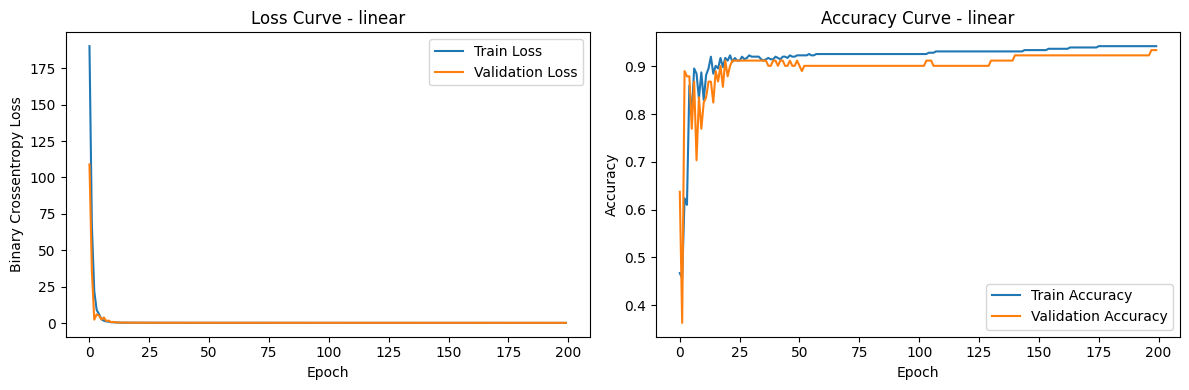

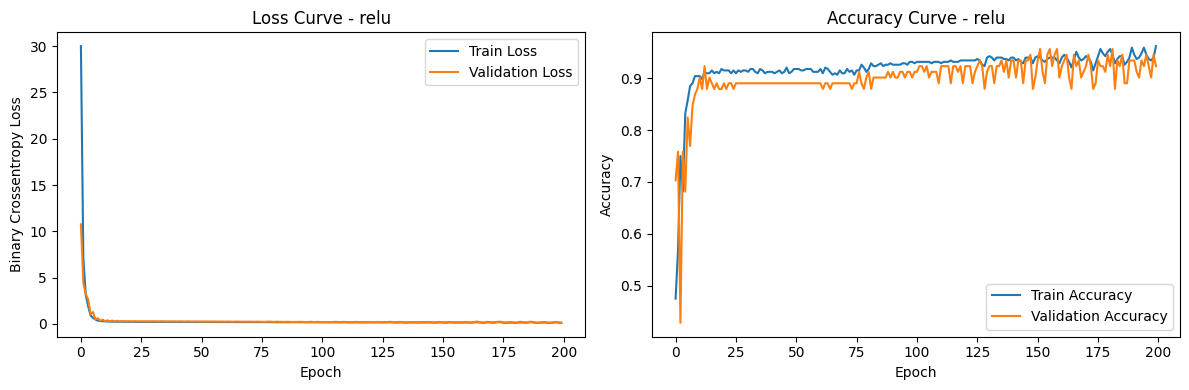

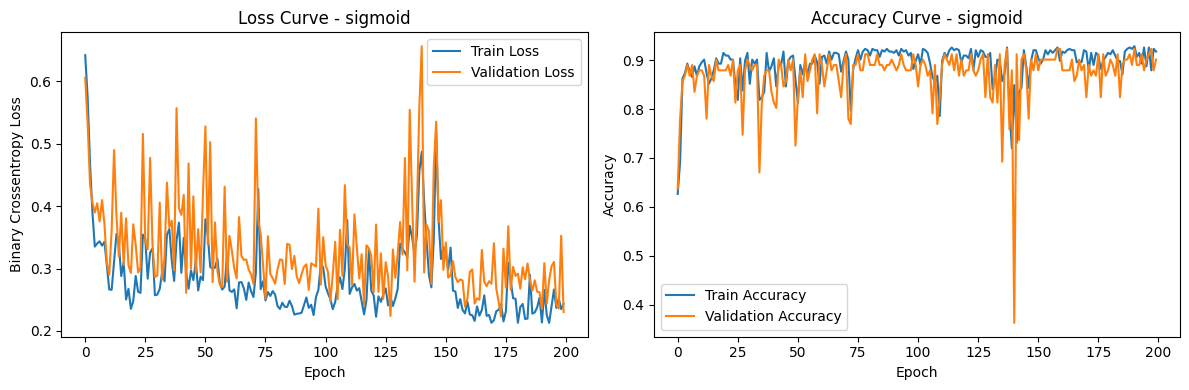

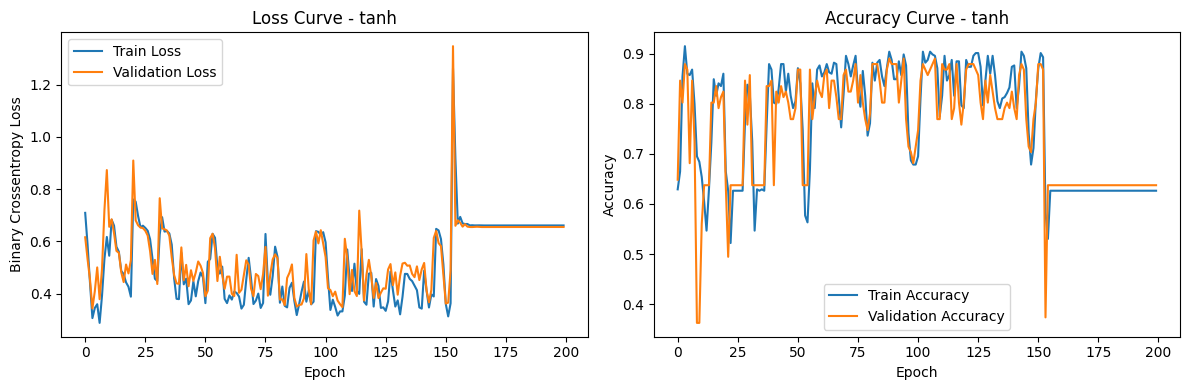

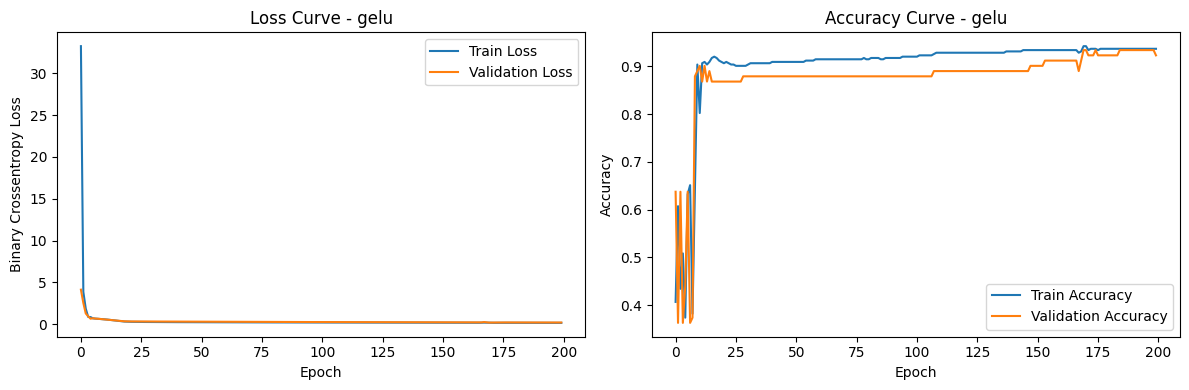

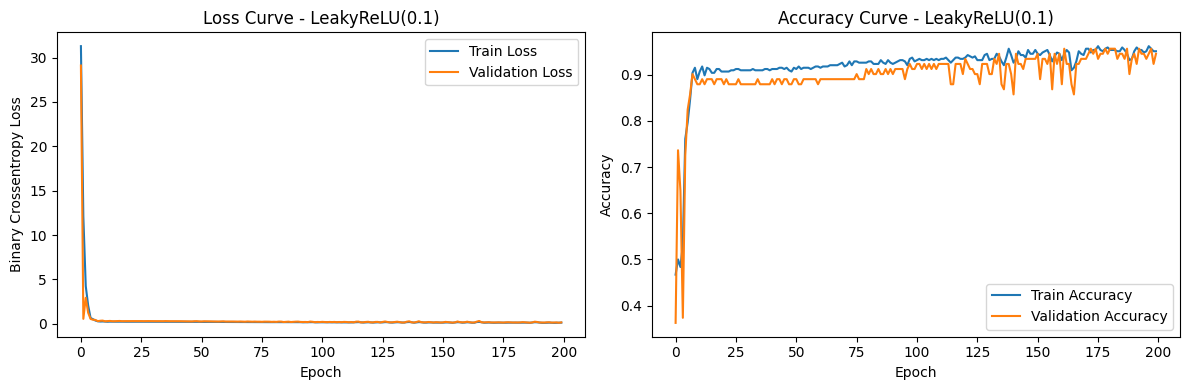

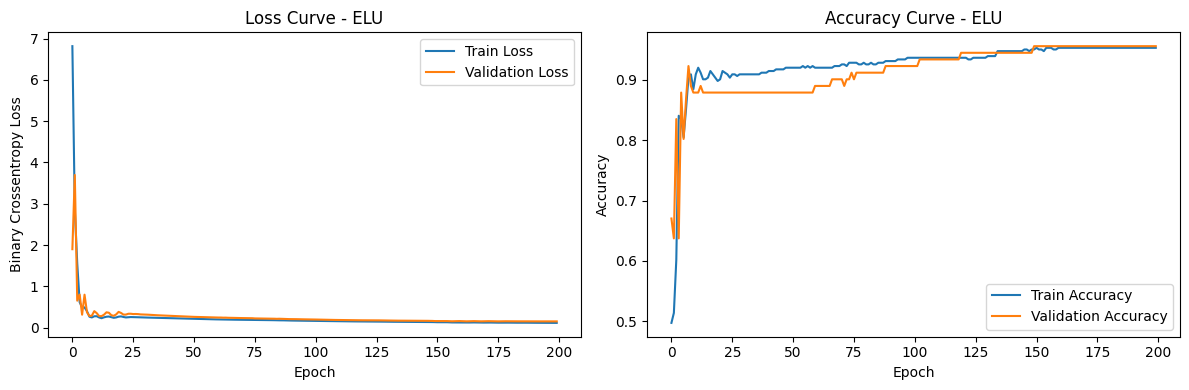

In [48]:

def plot_learning_curves(history, activation_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot Loss
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title(f'Loss Curve - {activation_name}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Binary Crossentropy Loss')
    ax1.legend()
    
    # Plot Accuracy
    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title(f'Accuracy Curve - {activation_name}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

for name in activation_names:
    plot_learning_curves(histories[name], name)

Across almost all configurations, the networks demonstrate extremely fast initial learning. Training loss typically plummets from initial extreme highs to below 0.5 within the first 10 to 15 epochs. This is accompanied by a steep climb in training accuracy, rapidly reaching the 85% to 90% range.

The highest-performing activation functions (such as ReLU and the linear baseline) show tightly coupled training and validation metrics throughout the entire training cycle. The validation loss generally plateaus between 0.11 and 0.20 without any significant upward divergence. This flatline behavior indicates robust generalization and an absence of late-stage overfitting.

The optimal configurations ultimately converge to peak training accuracies exceeding 0.95 and validation accuracies stabilizing consistently around the 0.94 to 0.95 mark.

Certain activation functions exhibit high instability and validation loss fluctuations (Tanh and Sigmoid).

The experiment demonstrates that the Rectified Linear Unit (ReLU) provides the most optimal feature extraction and optimization stability for this classification task. Furthermore, the highly robust performance and early convergence of the linear activation baseline confirm that the dataset's features are linearly separable. This mathematical renders more complex non-linearities (such as Sigmoid or Tanh) unnecessary, as they introduce gradient challenges.